# Conditional Transformer-Based Generation of 2D Platformer Level Segments

**Student:** Robert Mayfield  
**Dataset:** Video Game Level Corpus (VGLC): Super Mario Bros tile based level files  
**Model:** Conditional decoder-only Transformer with difficulty control tokens

## Project Overview

In [1]:
import json
import pickle
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [2]:
%matplotlib inline

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Dataset Loading and Inspection

In [4]:
def load_level_corpus(data_dir: Path) -> tuple[list[dict], dict]:
    """Load all VGLC level text files and tile specification from a directory.

    Parameters
    ----------
    data_dir : Path
        Directory containing level .txt files and smb.json tile spec.

    Returns
    -------
    levels : list[dict]
        Each dict has keys 'name' (str) and 'rows' (list of str).
    tile_spec : dict
        Tile character to property list mapping from smb.json.
    """
    data_dir = Path(data_dir)

    with open(data_dir / "smb.json") as f:
        tile_spec = json.load(f)["tiles"]

    levels = []
    for path in sorted(data_dir.glob("mario-*.txt")):
        with open(path) as f:
            rows = [line.rstrip("\n") for line in f.readlines()]
        levels.append({"name": path.stem, "rows": rows})

    return levels, tile_spec


DATA_DIR = Path("../data/raw")
levels, tile_spec = load_level_corpus(DATA_DIR)
print(f"Loaded {len(levels)} levels")
print(f"Tile vocabulary: {len(tile_spec)} tile types")

Loaded 15 levels
Tile vocabulary: 13 tile types


In [5]:
def inspect_level_corpus(levels: list[dict]) -> pd.DataFrame:
    """Return a DataFrame of per-level structural statistics.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    pd.DataFrame
        One row per level: name, rows, cols, total_tiles.
    """
    records = []
    for lvl in levels:
        row_count = len(lvl["rows"])
        col_count = max(len(r) for r in lvl["rows"]) if lvl["rows"] else 0
        records.append({
            "name": lvl["name"],
            "rows": row_count,
            "cols": col_count,
            "total_tiles": row_count * col_count,
        })
    return pd.DataFrame(records)


corpus_stats = inspect_level_corpus(levels)
print(corpus_stats.to_string(index=False))
print(f"\nRow height consistent: {corpus_stats['rows'].nunique() == 1} ({corpus_stats['rows'].iloc[0]} rows)")
print(f"Width range: {corpus_stats['cols'].min()} to {corpus_stats['cols'].max()} columns")
print(f"Total tiles in corpus: {corpus_stats['total_tiles'].sum():,}")

     name  rows  cols  total_tiles
mario-1-1    14   202         2828
mario-1-2    14   158         2212
mario-1-3    14   150         2100
mario-2-1    14   197         2758
mario-3-1    14   197         2758
mario-3-3    14   149         2086
mario-4-1    14   222         3108
mario-4-2    14   187         2618
mario-5-1    14   198         2772
mario-5-3    14   150         2100
mario-6-1    14   184         2576
mario-6-2    14   215         3010
mario-6-3    14   165         2310
mario-7-1    14   176         2464
mario-8-1    14   373         5222

Row height consistent: True (14 rows)
Width range: 149 to 373 columns
Total tiles in corpus: 40,922


In [6]:
def display_level(level: dict, max_cols: int = 80) -> None:
    """Print a level tile grid to stdout, truncated to max_cols width.

    Parameters
    ----------
    level : dict
        Level dict with keys 'name' and 'rows'.
    max_cols : int
        Maximum columns to display. Default 80.
    """
    n_rows = len(level["rows"])
    n_cols = len(level["rows"][0]) if level["rows"] else 0
    print(f"  {level['name']}  ({n_rows} rows x {n_cols} cols)")
    print("  " + "-" * min(max_cols, n_cols))
    for row in level["rows"]:
        print("  " + row[:max_cols])


print("Sample levels (first 80 columns):\n")
display_level(levels[0])
print()
display_level(levels[7])

Sample levels (first 80 columns):

  mario-1-1  (14 rows x 202 cols)
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  --------------------------------------------------------------------------------
  ----------------------Q---------------------------------------------------------
  --------------------------------------------------------------------------------
  -------------------------------------------------------------------------------E
  ----------------------------------------------------------------S---------------
  ----------------Q---S?SQS---------------------<>---------<>------------------S?S
  ----------------

In [7]:
def count_tile_frequencies(levels: list[dict]) -> Counter:
    """Count each tile character across the full corpus.

    Parameters
    ----------
    levels : list[dict]
        Level corpus as returned by load_level_corpus.

    Returns
    -------
    Counter
        Tile character to total count across all levels.
    """
    counts = Counter()
    for lvl in levels:
        for row in lvl["rows"]:
            counts.update(row)
    return counts


tile_counts = count_tile_frequencies(levels)
total_tiles = sum(tile_counts.values())

print(f"{'Tile':<6} {'Count':>8} {'Pct':>8}  Properties")
print("-" * 55)
for ch, count in tile_counts.most_common():
    props = ", ".join(tile_spec.get(ch, ["unknown"]))
    print(f"  {repr(ch):<4} {count:>8,} {count / total_tiles * 100:>7.2f}%  {props}")

Tile      Count      Pct  Properties
-------------------------------------------------------
  '-'    35,277   86.21%  passable, empty
  'X'     3,600    8.80%  solid, ground
  'S'       932    2.28%  solid, breakable
  'E'       275    0.67%  enemy, damaging, hazard, moving
  '['       186    0.45%  solid, left pipe, pipe
  ']'       186    0.45%  solid, right pipe, pipe
  'o'       166    0.41%  coin, collectable, passable
  '<'        85    0.21%  solid, top-left pipe, pipe
  '>'        85    0.21%  solid, top-right pipe, pipe
  'Q'        70    0.17%  solid, question block, empty question block
  '?'        31    0.08%  solid, question block, full question block
  'B'        16    0.04%  Cannon top, cannon, solid, hazard
  'b'        13    0.03%  Cannon bottom, cannon, solid


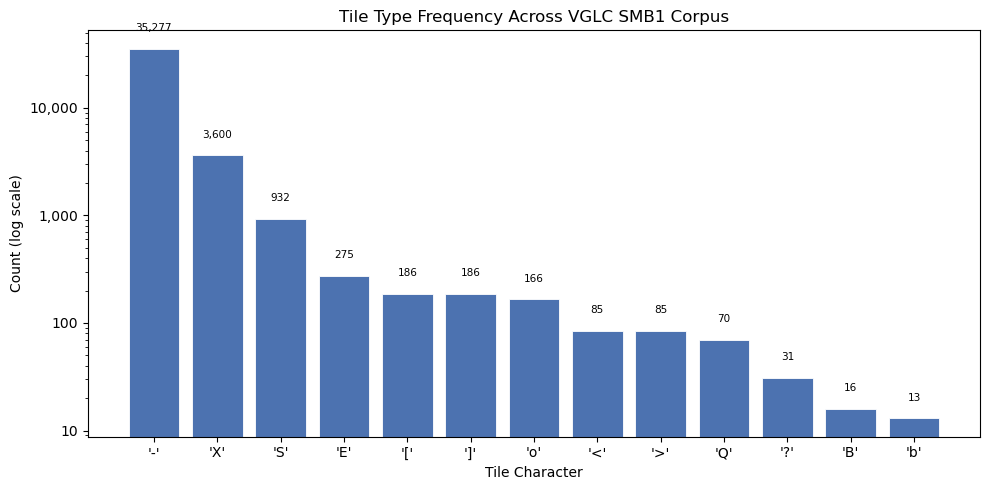

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

tile_labels = [repr(ch) for ch, _ in tile_counts.most_common()]
tile_values = [count for _, count in tile_counts.most_common()]

bars = ax.bar(tile_labels, tile_values, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("Tile Type Frequency Across VGLC SMB1 Corpus")
ax.set_xlabel("Tile Character")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, val in zip(bars, tile_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val * 1.4,
        f"{val:,}", ha="center", va="bottom", fontsize=7.5,
    )

plt.tight_layout()
plt.savefig("../outputs/figures/tile_frequency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=== ROW LENGTH CONSISTENCY ===")
for lvl in levels:
    lengths = [len(r) for r in lvl["rows"]]
    min_l, max_l = min(lengths), max(lengths)
    flag = "" if min_l == max_l else " <-- RAGGED"
    print(f"{lvl['name']}: min={min_l}, max={max_l}, consistent={min_l == max_l}{flag}")

print()
print("=== INVALID CHARACTERS ===")
valid_chars = set(tile_spec.keys())
for lvl in levels:
    chars = set(c for r in lvl["rows"] for c in r)
    invalid = chars - valid_chars
    status = f"invalid: {invalid}" if invalid else "clean"
    print(f"{lvl['name']}: {status}")

print()
print("=== EMPTY ROWS ===")
for lvl in levels:
    empty = [i for i, r in enumerate(lvl["rows"]) if len(r) == 0]
    status = f"empty at rows {empty}" if empty else "none"
    print(f"{lvl['name']}: {status}")


=== ROW LENGTH CONSISTENCY ===
mario-1-1: min=202, max=202, consistent=True
mario-1-2: min=158, max=158, consistent=True
mario-1-3: min=150, max=150, consistent=True
mario-2-1: min=197, max=197, consistent=True
mario-3-1: min=197, max=197, consistent=True
mario-3-3: min=149, max=149, consistent=True
mario-4-1: min=222, max=222, consistent=True
mario-4-2: min=187, max=187, consistent=True
mario-5-1: min=198, max=198, consistent=True
mario-5-3: min=150, max=150, consistent=True
mario-6-1: min=184, max=184, consistent=True
mario-6-2: min=215, max=215, consistent=True
mario-6-3: min=165, max=165, consistent=True
mario-7-1: min=176, max=176, consistent=True
mario-8-1: min=373, max=373, consistent=True

=== INVALID CHARACTERS ===
mario-1-1: clean
mario-1-2: clean
mario-1-3: clean
mario-2-1: clean
mario-3-1: clean
mario-3-3: clean
mario-4-1: clean
mario-4-2: clean
mario-5-1: clean
mario-5-3: clean
mario-6-1: clean
mario-6-2: clean
mario-6-3: clean
mario-7-1: clean
mario-8-1: clean

=== EMPTY 

The corpus contains 15 overworld platformer levels from Super Mario Bros, totaling 40,922 tiles. All levels share a consistent height of 14 rows, while widths range from 149 to 373 columns. The outlier is mario-8-1 at 373 columns, roughly twice the width of the average level, reflecting its role as the final world's extended gauntlet stage.

Tile distribution is heavily skewed toward the empty sky tile (`-`), which accounts for 86.21% of all tiles. Ground tiles (`X`) are second at 8.80%, followed by breakable blocks (`S`) at 2.28%. Interactive and hazard tiles such as enemies (`E`), pipes, coins, and question blocks together make up less than 3% of the corpus. The log scale on the chart is necessary to make the rarer tile types visible at all.

This extreme imbalance has a direct consequence for training: a model that predicts `-` for every token would achieve roughly 86% token level accuracy without learning any meaningful structure. Evaluation must therefore look beyond raw accuracy to structural validity, diversity, and difficulty alignment. The imbalance also means that rare tiles such as enemies and question blocks are underrepresented in training, which may limit the model's ability to place them correctly in generated output.

Data quality checks confirm the corpus is clean and ready for chunking. All rows within every level are uniform width with no ragged edges, all characters belong to the 13 tile vocabulary with no unexpected symbols, and no empty rows are present. No cleaning or imputation step is required before feature engineering.

## Level Feature Engineering

We split each level into fixed width chunks of 14 rows by 32 columns with a stride of 16 columns, then compute five structural features for each chunk: enemy density, hazard density, longest ground gap, solid tile ratio, and collectible density. These features drive the difficulty scoring in the next section.

In [11]:
# Derive tile category sets from tile_spec
SOLID_TILES      = {ch for ch, props in tile_spec.items() if "solid"       in props}
HAZARD_TILES     = {ch for ch, props in tile_spec.items() if "hazard"      in props}
ENEMY_TILES      = {ch for ch, props in tile_spec.items() if "enemy"       in props}
COLLECTIBLE_TILES = {ch for ch, props in tile_spec.items() if "collectable" in props}

print(f"Solid tiles:       {sorted(SOLID_TILES)}")
print(f"Hazard tiles:      {sorted(HAZARD_TILES)}")
print(f"Enemy tiles:       {sorted(ENEMY_TILES)}")
print(f"Collectible tiles: {sorted(COLLECTIBLE_TILES)}")


def chunk_level(level: dict, chunk_width: int = 32, stride: int = 16) -> list[dict]:
    """Split a level into fixed-width overlapping chunks.

    Parameters
    ----------
    level : dict
        Level dict with keys 'name' and 'rows' (list of str).
    chunk_width : int
        Number of tile columns per chunk. Default 32.
    stride : int
        Column step between chunk start positions. Default 16.

    Returns
    -------
    list[dict]
        Each dict has keys 'level_name', 'col_start', and 'rows'.
    """
    rows = level["rows"]
    n_cols = len(rows[0])
    chunks = []
    for start in range(0, n_cols - chunk_width + 1, stride):
        chunk_rows = [row[start:start + chunk_width] for row in rows]
        chunks.append({"level_name": level["name"], "col_start": start, "rows": chunk_rows})
    return chunks


all_chunks = [chunk for lvl in levels for chunk in chunk_level(lvl)]
print(f"Total chunks: {len(all_chunks)}")
print("Chunks per level:")
for lvl in levels:
    n = len(chunk_level(lvl))
    print(f"  {lvl['name']} ({len(lvl['rows'][0])} cols) -> {n} chunks")

Solid tiles:       ['<', '>', '?', 'B', 'Q', 'S', 'X', '[', ']', 'b']
Hazard tiles:      ['B', 'E']
Enemy tiles:       ['E']
Collectible tiles: ['o']
Total chunks: 161
Chunks per level:
  mario-1-1 (202 cols) -> 11 chunks
  mario-1-2 (158 cols) -> 8 chunks
  mario-1-3 (150 cols) -> 8 chunks
  mario-2-1 (197 cols) -> 11 chunks
  mario-3-1 (197 cols) -> 11 chunks
  mario-3-3 (149 cols) -> 8 chunks
  mario-4-1 (222 cols) -> 12 chunks
  mario-4-2 (187 cols) -> 10 chunks
  mario-5-1 (198 cols) -> 11 chunks
  mario-5-3 (150 cols) -> 8 chunks
  mario-6-1 (184 cols) -> 10 chunks
  mario-6-2 (215 cols) -> 12 chunks
  mario-6-3 (165 cols) -> 9 chunks
  mario-7-1 (176 cols) -> 10 chunks
  mario-8-1 (373 cols) -> 22 chunks


In [12]:
def compute_enemy_density(chunk_rows: list[str]) -> float:
    """Fraction of tiles that are enemies (E).

    Parameters
    ----------
    chunk_rows : list[str]
        Tile row strings for a single chunk.

    Returns
    -------
    float
    """
    total = len(chunk_rows) * len(chunk_rows[0])
    return sum(row.count("E") for row in chunk_rows) / total


def compute_hazard_density(chunk_rows: list[str]) -> float:
    """Fraction of tiles that are hazards (enemies and cannons).

    Parameters
    ----------
    chunk_rows : list[str]
        Tile row strings for a single chunk.

    Returns
    -------
    float
    """
    total = len(chunk_rows) * len(chunk_rows[0])
    return sum(sum(1 for c in row if c in HAZARD_TILES) for row in chunk_rows) / total


def compute_longest_gap(chunk_rows: list[str]) -> int:
    """Max consecutive empty columns in the ground row (bottom row).

    A gap is a run of '-' tiles in the bottom row, representing a pit
    the player must jump over.

    Parameters
    ----------
    chunk_rows : list[str]
        Tile row strings for a single chunk.

    Returns
    -------
    int
    """
    max_gap = current_gap = 0
    for tile in chunk_rows[-1]:
        if tile == "-":
            current_gap += 1
            max_gap = max(max_gap, current_gap)
        else:
            current_gap = 0
    return max_gap


def compute_solid_ratio(chunk_rows: list[str]) -> float:
    """Fraction of tiles that are solid (ground, blocks, pipes).

    Parameters
    ----------
    chunk_rows : list[str]
        Tile row strings for a single chunk.

    Returns
    -------
    float
    """
    total = len(chunk_rows) * len(chunk_rows[0])
    return sum(sum(1 for c in row if c in SOLID_TILES) for row in chunk_rows) / total


def compute_collectible_density(chunk_rows: list[str]) -> float:
    """Fraction of tiles that are collectibles (coins).

    Parameters
    ----------
    chunk_rows : list[str]
        Tile row strings for a single chunk.

    Returns
    -------
    float
    """
    total = len(chunk_rows) * len(chunk_rows[0])
    return sum(row.count("o") for row in chunk_rows) / total

In [13]:
def engineer_features(chunk: dict) -> dict:
    """Compute all structural features for a single level chunk.

    Parameters
    ----------
    chunk : dict
        Chunk dict with keys 'level_name', 'col_start', and 'rows'.

    Returns
    -------
    dict
        Keys: level_name, col_start, enemy_density, hazard_density,
        longest_gap, solid_ratio, collectible_density.
    """
    rows = chunk["rows"]
    return {
        "level_name":          chunk["level_name"],
        "col_start":           chunk["col_start"],
        "enemy_density":       compute_enemy_density(rows),
        "hazard_density":      compute_hazard_density(rows),
        "longest_gap":         compute_longest_gap(rows),
        "solid_ratio":         compute_solid_ratio(rows),
        "collectible_density": compute_collectible_density(rows),
    }


chunk_features = pd.DataFrame([engineer_features(c) for c in all_chunks])
print(f"chunk_features shape: {chunk_features.shape}")
print()
print(chunk_features.head(8).to_string(index=False))
print()
print("Feature summary:")
print(chunk_features.drop(columns=["level_name", "col_start"]).describe().round(4).to_string())

chunk_features shape: (161, 7)

level_name  col_start  enemy_density  hazard_density  longest_gap  solid_ratio  collectible_density
 mario-1-1          0       0.002232        0.002232            0     0.095982                  0.0
 mario-1-1         16       0.004464        0.004464            0     0.127232                  0.0
 mario-1-1         32       0.006696        0.006696            0     0.120536                  0.0
 mario-1-1         48       0.006696        0.006696            2     0.093750                  0.0
 mario-1-1         64       0.006696        0.006696            3     0.098214                  0.0
 mario-1-1         80       0.008929        0.008929            3     0.104911                  0.0
 mario-1-1         96       0.011161        0.011161            0     0.093750                  0.0
 mario-1-1        112       0.008929        0.008929            0     0.140625                  0.0

Feature summary:
       enemy_density  hazard_density  longest_gap 

Chunking produced 161 training samples across the 15 levels, ranging from 8 chunks for the shorter levels to 22 for mario-8-1. Each chunk is 14 rows by 32 columns, giving 448 tiles per sample.

Tile category derivation from the spec identified 10 solid tile types, 2 hazard types (enemies `E` and cannon tops `B`), 1 enemy type, and 1 collectible type. Hazard density and enemy density are nearly identical across all chunks because cannon tiles account for only 16 total tiles in the corpus, making `E` the dominant hazard by a wide margin.

The feature distributions reflect the sparse, structured nature of Mario level design. Enemy density averages 0.72% with a max of 2.23%, confirming that most chunks contain few or no enemies. Collectible density has a median of 0, meaning the majority of chunks contain no coins at all. Solid ratio spans from 3.8% to 52.5%, capturing the range from open sky sections to heavily platformed areas like those seen in mario-4-2.

Longest gap shows the most variance of any feature, with a standard deviation of 8.0 and a maximum of 32. A value of 32 means the entire bottom row of a chunk is empty, representing a continuous pit spanning the full chunk width. These pit chunks will be important markers for hard difficulty labeling. The 25th percentile is 0, confirming that most chunks have solid ground throughout.

## Difficulty Scoring and Labeling

We compute a heuristic difficulty score for each chunk using a weighted combination of enemy density, longest ground gap, and hazard density. Thresholds are set at the 33rd and 67th percentiles of the score distribution to ensure balanced class sizes across Easy, Medium, and Hard labels.

In [14]:
def compute_difficulty_score(row: dict) -> float:
    """Compute a heuristic difficulty score for a level chunk.

    Weights enemy density, longest ground gap, and hazard density as
    the primary difficulty signals derived from structural features.

    Parameters
    ----------
    row : dict
        Feature dict as produced by engineer_features, or a pd.Series row.

    Returns
    -------
    float
        Raw difficulty score. Higher values indicate harder chunks.
    """
    return (
        row["enemy_density"] * 40
        + row["longest_gap"] * 5
        + row["hazard_density"] * 30
    )


chunk_features["difficulty_score"] = chunk_features.apply(compute_difficulty_score, axis=1)
print("Difficulty score summary:")
print(chunk_features["difficulty_score"].describe().round(3).to_string())

Difficulty score summary:
count    161.000
mean      28.779
std       40.054
min        0.000
25%        1.094
50%       15.000
75%       30.469
max      160.000


In [15]:
EASY_THRESHOLD = chunk_features["difficulty_score"].quantile(1 / 3)
HARD_THRESHOLD = chunk_features["difficulty_score"].quantile(2 / 3)


def assign_difficulty_label(score: float) -> str:
    """Map a raw difficulty score to a categorical label.

    Thresholds are the 33rd and 67th percentiles of the corpus score
    distribution, ensuring roughly equal class sizes for training.

    Parameters
    ----------
    score : float
        Raw difficulty score from compute_difficulty_score.

    Returns
    -------
    str
        One of 'Easy', 'Medium', or 'Hard'.
    """
    if score < EASY_THRESHOLD:
        return "Easy"
    elif score < HARD_THRESHOLD:
        return "Medium"
    return "Hard"


chunk_features["difficulty_label"] = chunk_features["difficulty_score"].map(assign_difficulty_label)

print(f"Easy   < {EASY_THRESHOLD:.3f}")
print(f"Medium   {EASY_THRESHOLD:.3f} to {HARD_THRESHOLD:.3f}")
print(f"Hard   >= {HARD_THRESHOLD:.3f}")
print()
print("Class distribution:")
print(chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"]).to_string())

Easy   < 5.677
Medium   5.677 to 20.781
Hard   >= 20.781

Class distribution:
difficulty_label
Easy      54
Medium    52
Hard      55


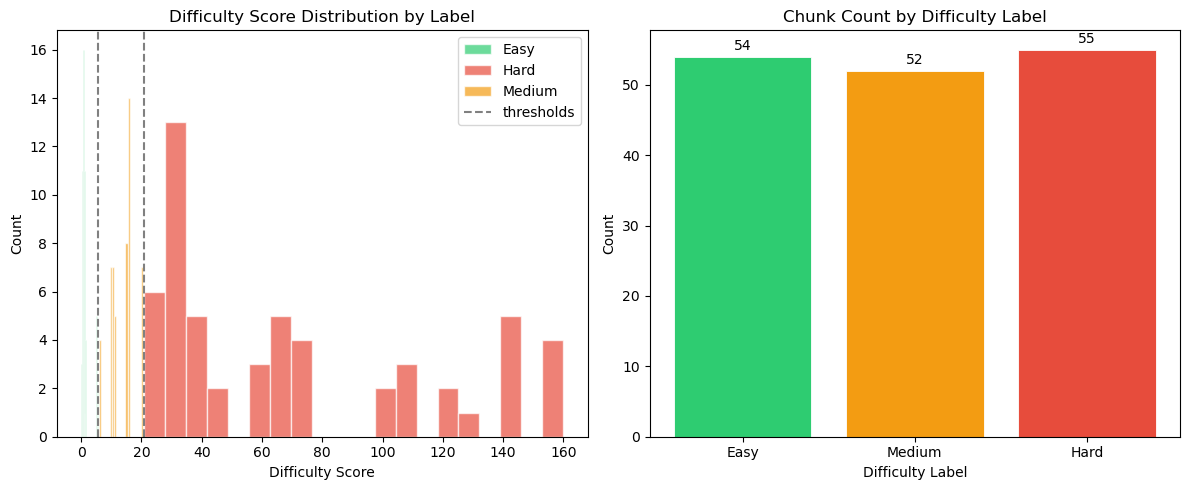

In [16]:
LABEL_COLORS = {"Easy": "#2ecc71", "Medium": "#f39c12", "Hard": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, grp in chunk_features.groupby("difficulty_label"):
    axes[0].hist(grp["difficulty_score"], bins=20, alpha=0.7,
                 label=label, color=LABEL_COLORS[label], edgecolor="white")
axes[0].axvline(EASY_THRESHOLD, color="gray", linestyle="--", linewidth=1.5, label="thresholds")
axes[0].axvline(HARD_THRESHOLD, color="gray", linestyle="--", linewidth=1.5)
axes[0].set_title("Difficulty Score Distribution by Label")
axes[0].set_xlabel("Difficulty Score")
axes[0].set_ylabel("Count")
axes[0].legend()

counts = chunk_features["difficulty_label"].value_counts().reindex(["Easy", "Medium", "Hard"])
bars = axes[1].bar(counts.index, counts.values,
                   color=[LABEL_COLORS[l] for l in counts.index],
                   edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 str(val), ha="center", va="bottom", fontsize=10)
axes[1].set_title("Chunk Count by Difficulty Label")
axes[1].set_xlabel("Difficulty Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/figures/difficulty_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The raw difficulty score is heavily right skewed, with a mean of 28.8, a median of 15.0, and a standard deviation of 40.1. The majority of chunks score near zero, while a small number of outliers reach up to 160. The highest scoring chunks belong to mario-1-3, mario-3-3, mario-5-3, and mario-6-3, which contain the largest ground gaps in the corpus. The single chunk with a longest_gap of 32 belongs to mario-6-3 at column offset 48.

Percentile thresholds produced a near perfectly balanced class distribution: 54 Easy, 52 Medium, and 55 Hard chunks out of 161 total. The Easy boundary falls at a score of 5.68, capturing chunks with little to no gap and minimal enemies. The Hard boundary falls at 20.78, separating chunks with moderate gaps and enemy placement from those with extended pits or dense hazards.

The longest gap feature dominates the score by design. Pit navigation is the primary mechanical challenge in Super Mario Bros, so weighting it heavily reflects the actual source of difficulty in the training data. The density features (enemy and hazard) contribute a small secondary signal, distinguishing chunks that are structurally similar in terms of gaps but differ in enemy placement.

These labels are heuristic approximations. They are derived from structural features rather than player playtesting, completion rates, or observed player behavior. A chunk labeled Hard by this system may not feel hard to an experienced player, and a chunk labeled Easy may still be challenging to a new player. This limitation is addressed further in the Limitations section.

## Tokenization and Data Pipeline

## Model Architecture

## Training

## Sample Generation

## Evaluation

## Failure Cases and Error Analysis

## Limitations, Bias, and Responsible Use

## Final Notebook Summary